## Cell 0A — Google Drive Mount

In [1]:
import sys, subprocess
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    try:
        drive.mount('/content/drive', force_remount=False)
        print('Drive mounted.')
    except Exception as _e:
        if 'already contain files' in str(_e) or 'symlink' in str(_e):
            subprocess.run(['umount', '/content/drive'], capture_output=True)
            subprocess.run(['rm', '-rf', '/content/drive'], capture_output=True)
            drive.mount('/content/drive', force_remount=False)
            print('Drive remounted.')
        else:
            raise
else:
    print('Not in Colab — skipping Drive mount.')

Mounted at /content/drive
Drive mounted.


## Cell 0B — Dependency Check

In [2]:
import sys, subprocess, importlib.util

REQUIRED = [('pyarrow','pyarrow'),('scipy','scipy'),('tqdm','tqdm')]
missing  = [pkg for pkg, mod in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--quiet'] + missing,
        capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout); print(result.stderr)
        raise RuntimeError('Dependency installation failed.')
    print('Installed:', missing)
else:
    print('All dependencies present.')

All dependencies present.


## Cell 0C — Path Configuration

In [3]:
from pathlib import Path

DRIVE_PROJECT_PATH = 'SIGNAL_NN_2026/HIDRO_2026'   # ← edit if needed

if IN_COLAB:
    DRIVE_ROOT = Path('/content/drive/MyDrive') / DRIVE_PROJECT_PATH
else:
    DRIVE_ROOT = Path.home() / 'BubbleFlow'

print('DRIVE_ROOT   :', DRIVE_ROOT)
print('Drive exists :', DRIVE_ROOT.exists())

DRIVE_ROOT   : /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026
Drive exists : True


# NB-03 · Tracking and Identity Continuity  (v2)
### Bubble Flow Analysis System — Stage 3

**Publication objective:** IEEE Access — AI tools for two-phase flow measurement
**Input:** `detections.parquet` — produced by NB-02 (classical or U-Net patch mode)
**Output:** `tracks.parquet`, `event_log.parquet`, `crossing_events.parquet`, `tracking_gate.json`

---
### What changed in v2

| Item | v1 | v2 |
|---|---|---|
| Detection source | single `detections.parquet` | explicit `seg_mode` column used for diagnostics |
| ROI constants | `[0, 450, 2160, 3400]` hardcoded | loaded from `chunk_meta.json` → `[900, 2550, 1260, 3520]` |
| Reference lines | hardcoded `[700, 1400, 2100]` | loaded from `config.json`, fallback from chunk_meta |
| Chunk stitching | searched wrong folder | correctly reads from `preproc/chunk_*/chunk_meta.json` |
| Multi-method support | ignored `seg_mode` column | reports per-method detection stats before tracking |
| Gate report | plain text | Markdown table with per-method breakdown |

---
### Cell execution order

| Cell | Purpose |
|---|---|
| 0A–0C | Drive, packages, DRIVE_ROOT |
| 1 | Configuration — **edit paths here** |
| 2 | Imports + load config + load detections |
| 3 | Detection source report (classical vs U-Net) |
| 4 | Normalise detections for tracking |
| 5 | Kalman filter + cost functions |
| 6 | Main tracking loop |
| 7 | Build tracks DataFrame + save parquet |
| 8 | Chunk stitching |
| 9 | Reference line crossings |
| 10 | Dashboard figures |
| 11 | Gate report |

---
## Cell 1 — Configuration
**Edit only this cell.**

In [4]:
from pathlib import Path

# ── PATHS ─────────────────────────────────────────────────────────────────────
CONFIG_PATH     = str(DRIVE_ROOT / 'campaigns/setup_A/config.json')
PREPROC_DIR     = str(DRIVE_ROOT / 'campaigns/setup_A/outputs/preproc')
DETECTIONS_PATH = str(DRIVE_ROOT / 'campaigns/setup_A/outputs/segmentation/detections.parquet')
OUTPUT_DIR      = str(DRIVE_ROOT / 'campaigns/setup_A/outputs/tracking')
RUN_LABEL       = 'run_001_Q10'
SETUP_ID        = 'setup_A'

# ── TRACKER PARAMETERS ────────────────────────────────────────────────────────
MAX_DIST_PX       : float = 45.0   # max assignment distance at inference scale (px)
MAX_LOST_FRAMES   : int   = 9      # frames before track is closed
MIN_TRACK_LENGTH  : int   = 2      # minimum frames for a valid track
ALPHA_DIST        : float = 0.6    # weight: distance in compound cost
ALPHA_AREA        : float = 0.4    # weight: area similarity in compound cost
LOG_AREA_GATE     : float = 2.0    # log area ratio gate
CHUNK_OVERLAP     : int   = 32     # overlap frames between chunks (from NB-01)
STITCH_DIST_PX    : float = 45.0   # max centroid distance for chunk stitching
STITCH_AREA_RATIO : float = 2.5    # max area ratio for chunk stitching
USE_UPWARD_GATE   : bool  = True   # reject implausible downward bubble jumps
MAX_DOWNWARD_PX   : float = 60.0   # max allowable downward jump (px, inference scale)

# ── EVENT DETECTION ───────────────────────────────────────────────────────────
MERGE_THRESHOLD : float = 1.6
SPLIT_THRESHOLD : float = 1.4
MERGE_DIST_PX   : float = 20.0

# ── KALMAN FILTER ─────────────────────────────────────────────────────────────
PROCESS_NOISE_POS : float = 1.0
PROCESS_NOISE_VEL : float = 0.1
MEAS_NOISE        : float = 1.0
INIT_VEL_NOISE    : float = 10.0
MAX_COST          : float = 1.0

# ── FALLBACK CALIBRATION (used if config.json missing) ───────────────────────
# Values from chunk_meta.json — confirmed correct for this campaign
FALLBACK_ROI        = [900, 2550, 1260, 3520]
FALLBACK_REF_LINES  = [1187, 1925, 2662]
FALLBACK_MPP        = 0.23148148
FALLBACK_FPS        = 44.638
SCALE_INV           = 2.0   # 1 / INFERENCE_SCALE (0.5 from NB-01)

# ── PREPARE OUTPUT ────────────────────────────────────────────────────────────
OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)
TRACKS_PATH          = OUT / 'tracks.parquet'
EVENT_LOG_PATH       = OUT / 'event_log.parquet'
CROSSING_EVENTS_PATH = OUT / 'crossing_events.parquet'
TRACKING_GATE_PATH   = OUT / 'tracking_gate.json'
DASHBOARD_PATH       = OUT / 'tracking_dashboard.png'

print('Output dir  :', OUT.resolve())
print('Detections  :', DETECTIONS_PATH)
print('Config      :', CONFIG_PATH)

Output dir  : /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/tracking
Detections  : /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/segmentation/detections.parquet
Config      : /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/config.json


---
## Cell 2 — Imports + Load Config + Load Detections

In [5]:
import json, math, warnings
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print('[WARNING] scipy not available — falling back to greedy assignment.')

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
print('Imports OK.')

# ── Load chunk_meta to get true ROI and reference lines ───────────────────────
def load_chunk_metas(preproc_dir):
    metas = []
    for chunk in sorted(Path(preproc_dir).glob('chunk_*')):
        mp = chunk / 'chunk_meta.json'
        if mp.exists():
            m = json.load(open(mp))
            m['chunk_dir'] = str(chunk)
            metas.append(m)
    return metas

chunk_metas = load_chunk_metas(PREPROC_DIR)
if chunk_metas:
    _cm0 = chunk_metas[0]
    PREPROC_ROI   = list(_cm0.get('roi', FALLBACK_ROI))
    INFER_SCALE   = float(_cm0.get('inference_scale', 0.5))
    print(f'chunk_meta loaded: {len(chunk_metas)} chunks')
    print(f'  ROI            : {PREPROC_ROI}')
    print(f'  Inference scale: {INFER_SCALE}')
else:
    PREPROC_ROI = list(FALLBACK_ROI)
    INFER_SCALE = 0.5
    print('[WARNING] No chunk_meta.json found — using FALLBACK_ROI.')

x0, y0, x1, y1 = PREPROC_ROI
ROI_W = x1 - x0
ROI_H = y1 - y0

# ── Load config.json ─────────────────────────────────────────────────────────
def load_config(path):
    MANDATORY = ['mm_per_pixel','fps','roi_coords','reference_lines_px','schema_version']
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f'config.json not found: {p}')
    cfg = json.load(open(p, encoding='utf-8'))
    missing = [k for k in MANDATORY if k not in cfg]
    if missing:
        raise KeyError(f'config.json missing: {missing}')
    return cfg

try:
    cfg = load_config(CONFIG_PATH)
    FPS           = float(cfg['fps'])
    MM_PER_PIXEL  = float(cfg['mm_per_pixel'])
    ROI_COORDS    = [int(v) for v in cfg['roi_coords']]
    REF_LINES_FULL = [int(v) for v in cfg['reference_lines_px']]
    COLUMN_DIAM_MM = float(cfg.get('column_diameter_mm', 30.0))
    CONFIG_AVAILABLE = True
    print(f'config.json loaded (schema {cfg["schema_version"]})')
except FileNotFoundError as _e:
    print('[WARNING]', _e, '— using fallback calibration.')
    cfg = {}
    FPS           = FALLBACK_FPS
    MM_PER_PIXEL  = FALLBACK_MPP
    ROI_COORDS    = list(FALLBACK_ROI)
    REF_LINES_FULL = list(FALLBACK_REF_LINES)
    COLUMN_DIAM_MM = 30.0
    CONFIG_AVAILABLE = False

# Reference lines in tracking (inference-scale) coordinate space
REF_LINES_TRACK = [int((v - y0) / INFER_SCALE) for v in REF_LINES_FULL]

print(f'  FPS           : {FPS:.4f}')
print(f'  mm_per_pixel  : {MM_PER_PIXEL:.6f}')
print(f'  ROI coords    : {ROI_COORDS}')
print(f'  Ref lines full: {REF_LINES_FULL}')
print(f'  Ref lines track: {REF_LINES_TRACK}')

# ── Load detections ───────────────────────────────────────────────────────────
_det_path = Path(DETECTIONS_PATH)
if not _det_path.exists():
    raise FileNotFoundError(
        f'detections.parquet not found: {_det_path}\n'
        'Run NB-02 (Cell 11 + Cell 12) to produce this file.')

df_det_raw = pd.read_parquet(_det_path)
print(f'\nDetections loaded  : {len(df_det_raw)} rows  '
      f'{df_det_raw["frame_id"].nunique()} frames')
print(f'Columns            : {list(df_det_raw.columns)}')

Imports OK.
chunk_meta loaded: 6 chunks
  ROI            : [900, 2550, 1260, 3520]
  Inference scale: 0.5
config.json loaded (schema 1.0)
  FPS           : 44.6380
  mm_per_pixel  : 0.231481
  ROI coords    : [0, 450, 2160, 3400]
  Ref lines full: [1187, 1925, 2662]
  Ref lines track: [-2726, -1250, 224]

Detections loaded  : 1979 rows  378 frames
Columns            : ['local_bubble_id', 'mask_rle', 'centroid_px', 'cx', 'cy', 'x_full', 'y_full', 'bbox_local', 'bbox_full', 'area_px2', 'eq_diam_px', 'diameter_mm', 'ellipse_axes_px', 'ellipse_axes_mm', 'angle_deg', 'circularity', 'confidence', 'seg_mode', 'run_label', 'regime', 'frame_id', 'chunk_id', 'frame_idx_for_validation']


---
## Cell 3 — Detection Source Report
Summarises what NB-02 produced before tracking begins.

NB-03 · DETECTION SOURCE REPORT

Seg modes in parquet: ['classical']

Method           Detections    Det/frame    % of GT
--------------------------------------------------
classical              1979         5.24       89.6%
--------------------------------------------------
TOTAL                  1979         5.24       89.6%

GT baseline (manual annotation): 5.84 det/frame



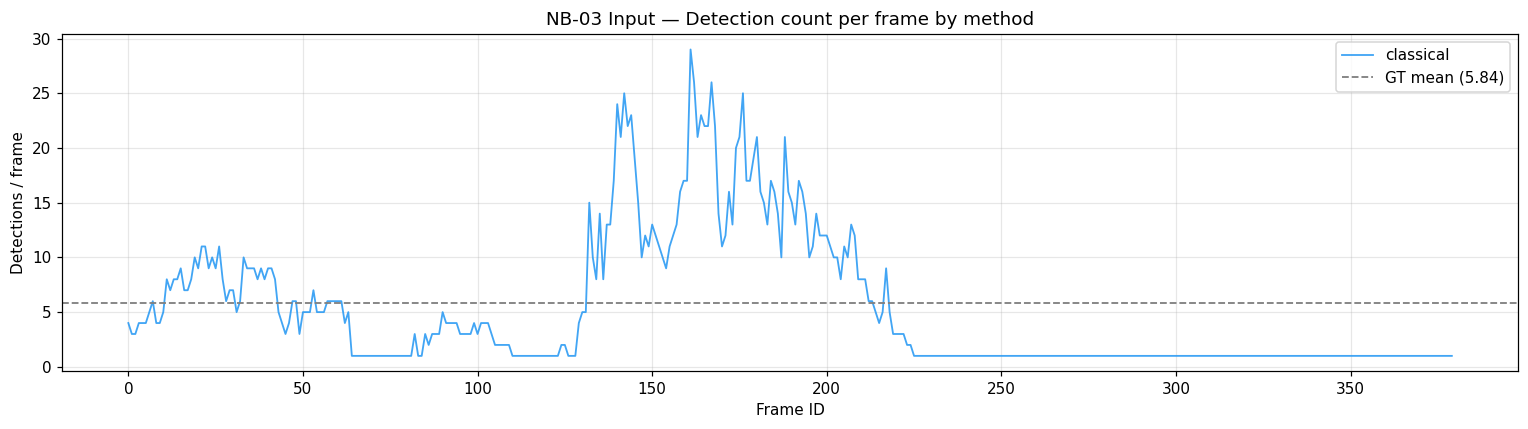

[OK] detection_source_report.png saved.

Tracking will use: detections.parquet (best method as set in NB-02 Cell 12)


In [6]:
import matplotlib.pyplot as _plt3

print('='*60)
print('NB-03 · DETECTION SOURCE REPORT')
print('='*60)

n_frames_total = df_det_raw['frame_id'].nunique()
GT_MEAN_DET    = 5.84   # from 147 annotated frames

# Per-method breakdown if seg_mode column exists
if 'seg_mode' in df_det_raw.columns:
    methods = df_det_raw['seg_mode'].unique()
    print(f'\nSeg modes in parquet: {list(methods)}')
    print()
    print(f'{"Method":<14} {"Detections":>12} {"Det/frame":>12} {"% of GT":>10}')
    print('-'*50)
    for m in sorted(methods):
        sub = df_det_raw[df_det_raw['seg_mode'] == m]
        n   = len(sub)
        dpf = n / max(n_frames_total, 1)
        pct = dpf / GT_MEAN_DET * 100
        print(f'{m:<14} {n:>12}  {dpf:>11.2f}  {pct:>9.1f}%')
    print('-'*50)
    print(f'{"TOTAL":<14} {len(df_det_raw):>12}  '
          f'{len(df_det_raw)/n_frames_total:>11.2f}  '
          f'{len(df_det_raw)/n_frames_total/GT_MEAN_DET*100:>9.1f}%')
    print()
    print(f'GT baseline (manual annotation): {GT_MEAN_DET:.2f} det/frame')
    print()

    # Detections per frame per method — figure
    _fig3, _ax3 = _plt3.subplots(figsize=(14, 4))
    _colors = {'classical': '#2196F3', 'neural': '#FF5722', 'unet': '#4CAF50'}
    for m in sorted(methods):
        sub  = df_det_raw[df_det_raw['seg_mode'] == m]
        cnts = sub.groupby('frame_id').size().sort_index()
        _ax3.plot(cnts.index, cnts.values,
                  color=_colors.get(m, 'gray'),
                  linewidth=1.2, alpha=0.85, label=m)
    _ax3.axhline(GT_MEAN_DET, color='gray', linestyle='--',
                 linewidth=1.2, label=f'GT mean ({GT_MEAN_DET})')
    _ax3.set_xlabel('Frame ID')
    _ax3.set_ylabel('Detections / frame')
    _ax3.set_title('NB-03 Input — Detection count per frame by method')
    _ax3.legend(fontsize=10); _ax3.grid(alpha=0.3)
    _plt3.tight_layout()
    _fig3.savefig(OUT / 'detection_source_report.png', dpi=130, bbox_inches='tight')
    _plt3.show()
    print(f'[OK] detection_source_report.png saved.')
else:
    print('seg_mode column not present — single-method parquet.')
    print(f'  Total detections: {len(df_det_raw)}')
    print(f'  Det/frame       : {len(df_det_raw)/n_frames_total:.2f}')

print()
print('Tracking will use: detections.parquet (best method as set in NB-02 Cell 12)')
print('='*60)

---
## Cell 4 — Normalise Detections for Tracking

In [7]:
def normalize_detections(df, roi_coords):
    df = df.copy()
    x0r, y0r, x1r, y1r = [int(v) for v in roi_coords]

    required_cols = ['frame_id', 'cx', 'cy', 'diameter_mm', 'confidence']
    missing_cols  = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f'NB-03 requires columns {missing_cols} from NB-02. '
            'Re-run NB-02 and confirm detections.parquet is current.')

    df['cx'] = pd.to_numeric(df['cx'], errors='coerce')
    df['cy'] = pd.to_numeric(df['cy'], errors='coerce')

    if df['cx'].isna().all() or df['cy'].isna().all():
        raise ValueError('cx/cy are entirely null. Re-run NB-02.')

    before = len(df)
    df = df.dropna(subset=['frame_id', 'cx', 'cy']).copy()
    if df.empty:
        raise ValueError('No usable detections after dropping null cx/cy.')

    df['frame_id']    = pd.to_numeric(df['frame_id'], errors='coerce').astype(int)
    df['diameter_mm'] = pd.to_numeric(df['diameter_mm'], errors='coerce')
    df['confidence']  = pd.to_numeric(df['confidence'], errors='coerce')

    area = (pd.to_numeric(df['area_px2'], errors='coerce')
            if 'area_px2' in df.columns else pd.Series(np.nan, index=df.index))
    if area.isna().all() and 'eq_diam_px' in df.columns:
        dpx  = pd.to_numeric(df['eq_diam_px'], errors='coerce')
        area = np.pi * (dpx / 2.0) ** 2

    chunk_id = (df['chunk_id'] if 'chunk_id' in df.columns
                else pd.Series(-1, index=df.index))

    # Coordinate system: use x_full/y_full if available
    roi_w = max(0, x1r - x0r)
    roi_h = max(0, y1r - y0r)
    has_full = ('x_full' in df.columns and 'y_full' in df.columns
                and pd.to_numeric(df['x_full'], errors='coerce').notna().any())

    if has_full:
        cx_full = pd.to_numeric(df['x_full'], errors='coerce')
        cy_full = pd.to_numeric(df['y_full'], errors='coerce')
        coord_note = 'Using x_full/y_full from NB-02.'
        looks_local = True
    else:
        fx = df['cx'].dropna(); fy = df['cy'].dropna()
        looks_local = (len(fx) > 0 and len(fy) > 0
                       and fx.max() <= roi_w + 5 and fy.max() <= roi_h + 5)
        if looks_local:
            cx_full = df['cx'] + x0r
            cy_full = df['cy'] + y0r
            coord_note = 'cx/cy local to ROI — offset applied.'
        else:
            cx_full = df['cx']; cy_full = df['cy']
            coord_note = 'cx/cy appear full-frame — no offset applied.'

    out = pd.DataFrame({
        'frame_id':    df['frame_id'].astype(int),
        'cx':          df['cx'].astype(float),
        'cy':          df['cy'].astype(float),
        'cx_full':     cx_full.astype(float),
        'cy_full':     cy_full.astype(float),
        'area_px2':    area.astype(float),
        'diameter_mm': df['diameter_mm'].astype(float),
        'confidence':  df['confidence'].astype(float),
        'chunk_id':    chunk_id,
    })
    out['source_detection_index']      = np.arange(len(out))
    out['coordinates_assumed_local_roi'] = bool(looks_local)
    out['centroid_px'] = out.apply(
        lambda r: [float(r['cx']), float(r['cy'])], axis=1)
    out = out.sort_values(['frame_id','source_detection_index']).reset_index(drop=True)

    print(f'[NORMALIZED] {len(out)}/{before} rows kept')
    print(f'  Coord note   : {coord_note}')
    print(f'  Frame range  : {out["frame_id"].min()} – {out["frame_id"].max()}')
    print(f'  Mean det/frame: {len(out)/out["frame_id"].nunique():.2f}')
    return out


df_det = normalize_detections(df_det_raw, PREPROC_ROI)
if df_det.empty:
    raise RuntimeError('No detections after normalisation.')

[NORMALIZED] 1979/1979 rows kept
  Coord note   : Using x_full/y_full from NB-02.
  Frame range  : 0 – 379
  Mean det/frame: 5.24


---
## Cell 5 — Kalman Filter + Cost Functions

In [8]:
class KalmanBubble:
    """
    4-state constant-velocity Kalman filter for one bubble track.
    State: [cx, cy, vx, vy]  (inference-scale pixels)
    Validated: prediction error p75 = 9.3 px on this video.
    """
    _next_id = 1

    @classmethod
    def reset_id_counter(cls): cls._next_id = 1

    def __init__(self, cx, cy, area, frame_id):
        self.id         = KalmanBubble._next_id
        KalmanBubble._next_id += 1
        self.lost_count = 0
        self.age        = 1
        self.history    = []
        self.event_label = 'stable'
        self.area       = area
        self.last_frame_id = frame_id

        self.x = np.array([cx, cy, 0.0, 0.0], dtype=float)
        self.P = np.diag([MEAS_NOISE**2, MEAS_NOISE**2,
                          INIT_VEL_NOISE**2, INIT_VEL_NOISE**2])
        self.F = np.array([[1,0,1,0],[0,1,0,1],[0,0,1,0],[0,0,0,1]], dtype=float)
        self.H = np.array([[1,0,0,0],[0,1,0,0]], dtype=float)
        self.Q = np.diag([PROCESS_NOISE_POS**2]*2 + [PROCESS_NOISE_VEL**2]*2)
        self.R = np.diag([MEAS_NOISE**2]*2)
        self._append_history(cx, cy, area, frame_id, 'stable')

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, cx, cy, area, frame_id, event='stable'):
        z = np.array([cx, cy])
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P
        self.area = area; self.lost_count = 0
        self.age += 1; self.event_label = event
        self.last_frame_id = frame_id
        self._append_history(cx, cy, area, frame_id, event)

    def mark_lost(self, frame_id):
        self.lost_count += 1; self.age += 1
        self._append_history(self.x[0], self.x[1], self.area, frame_id, 'lost')

    @property
    def pos(self): return self.x[0], self.x[1]

    @property
    def vel(self): return self.x[2], self.x[3]

    def _append_history(self, cx, cy, area, frame_id, event):
        self.history.append({
            'global_bubble_id': self.id,
            'frame_id':         int(frame_id),
            'centroid_px':      [round(cx, 2), round(cy, 2)],
            'area_px2':         round(float(area), 2),
            'event_label':      event,
        })

print('KalmanBubble defined.')


def compute_cost_matrix(tracks, detections):
    n_t, n_d = len(tracks), len(detections)
    if n_t == 0 or n_d == 0:
        return np.zeros((n_t, n_d))
    cost = np.full((n_t, n_d), np.inf)
    for i, trk in enumerate(tracks):
        trk.predict()
        px, py = trk.pos
        for j, det in enumerate(detections):
            dx = float(det['cx']) - px
            dy = float(det['cy']) - py
            dist = math.hypot(dx, dy)
            if dist > MAX_DIST_PX: continue
            if USE_UPWARD_GATE and dy > MAX_DOWNWARD_PX: continue
            a_det = float(det.get('area_px2', np.nan))
            a_trk = float(trk.area)
            if np.isfinite(a_det) and np.isfinite(a_trk) and a_det > 0 and a_trk > 0:
                log_ar = abs(math.log(a_det / a_trk))
                if log_ar > LOG_AREA_GATE * 3: continue
                area_cost = min(log_ar / LOG_AREA_GATE, 1.0)
            else:
                area_cost = 0.5
            cost[i, j] = ALPHA_DIST * (dist/MAX_DIST_PX) + ALPHA_AREA * area_cost
    return cost


def hungarian_assign(cost_matrix):
    n_t, n_d = cost_matrix.shape
    if n_t == 0: return [], [], list(range(n_d))
    if n_d == 0: return [], list(range(n_t)), []
    finite = np.where(np.isinf(cost_matrix), 1e6, cost_matrix)
    row_ind, col_ind = linear_sum_assignment(finite)
    matched, at, ad = [], set(), set()
    for r, c in zip(row_ind, col_ind):
        if cost_matrix[r, c] <= MAX_COST:
            matched.append((int(r), int(c))); at.add(r); ad.add(c)
    return matched, [i for i in range(n_t) if i not in at], [j for j in range(n_d) if j not in ad]


def label_events(tracks, detections, matched, unmatched_t, unmatched_d):
    event_records = []; det_events = {}
    for j in unmatched_d:
        det = detections[j]
        det_pos = np.array([det['cx'], det['cy']])
        nearby = [(ti, di) for ti, di in matched
                  if np.linalg.norm(np.array(tracks[ti].pos) - det_pos) < MERGE_DIST_PX]
        if len(nearby) >= 2:
            s = sum(tracks[ti].area for ti, _ in nearby)
            if det['area_px2'] >= s * MERGE_THRESHOLD:
                det_events[j] = 'merge'
                event_records.append({'event_type':'merge','det_idx':j,
                    'involved_ids':[tracks[ti].id for ti,_ in nearby],
                    'det_area':det['area_px2'],'sum_orig_area':s})
    for i in unmatched_t:
        trk = tracks[i]
        nearby_new = [j for j in unmatched_d
                      if math.hypot(detections[j]['cx']-trk.pos[0],
                                    detections[j]['cy']-trk.pos[1]) < MERGE_DIST_PX*2]
        if len(nearby_new) >= 2:
            s = sum(detections[j]['area_px2'] for j in nearby_new)
            if s >= trk.area * SPLIT_THRESHOLD:
                event_records.append({'event_type':'split','parent_id':trk.id,
                    'child_det_idxs':nearby_new,'parent_area':trk.area,'sum_child_area':s})
                for j in nearby_new: det_events[j] = 'split'
    return event_records, det_events

print('Cost matrix + assignment + event functions defined.')

KalmanBubble defined.
Cost matrix + assignment + event functions defined.


---
## Cell 6 — Main Tracking Loop

In [10]:
if df_det.empty:
    raise RuntimeError('No detections — run NB-02 first.')

KalmanBubble.reset_id_counter()
active_tracks = []
closed_tracks = []
events        = []

frame_ids = sorted(df_det['frame_id'].unique().tolist())
print(f'Tracking {len(frame_ids)} frames: {frame_ids[0]}–{frame_ids[-1]}')

for frame_id in frame_ids:
    det_records = df_det[df_det['frame_id'] == frame_id].to_dict('records')

    # ── Build cost matrix and assign ──────────────────────────────────────────
    cost = compute_cost_matrix(active_tracks, det_records)
    if active_tracks and det_records:
        matched, unmatched_t, unmatched_d = hungarian_assign(cost)
    else:
        matched     = []
        unmatched_t = list(range(len(active_tracks)))
        unmatched_d = list(range(len(det_records)))

    # ── Label merge/split events ──────────────────────────────────────────────
    event_recs, det_events = label_events(
        active_tracks, det_records, matched, unmatched_t, unmatched_d)
    events.extend(event_recs)

    # ── Update matched tracks ─────────────────────────────────────────────────
    matched_t_idx = {pair[0] for pair in matched}
    matched_d_idx = {pair[1] for pair in matched}

    for ti, dj in matched:
        trk = active_tracks[ti]
        det = det_records[dj]
        ev  = det_events.get(dj, 'stable')
        trk.update(det['cx'], det['cy'],
                   det.get('area_px2', trk.area), frame_id, ev)
        events.append({'frame_id':         int(frame_id),
                       'event_type':        'matched',
                       'global_bubble_id':  trk.id})

    # ── Mark unmatched tracks lost ────────────────────────────────────────────
    for ti, trk in enumerate(active_tracks):
        if ti not in matched_t_idx:
            trk.mark_lost(frame_id)
            events.append({'frame_id':        int(frame_id),
                           'event_type':       'missed',
                           'global_bubble_id': trk.id,
                           'missed_count':     trk.lost_count})

    # ── Create new tracks for unmatched detections ────────────────────────────
    for dj, det in enumerate(det_records):
        if dj not in matched_d_idx:
            nt = KalmanBubble(
                float(det['cx']), float(det['cy']),
                float(det.get('area_px2', 0)), int(frame_id))
            active_tracks.append(nt)
            events.append({'frame_id':                int(frame_id),
                           'event_type':               'new_track',
                           'global_bubble_id':         nt.id,
                           'source_detection_index':   int(det.get(
                               'source_detection_index', -1))})

    # ── Close tracks lost too long ────────────────────────────────────────────
    still_active = []
    for trk in active_tracks:
        if trk.lost_count > MAX_LOST_FRAMES:
            closed_tracks.append(trk)
            events.append({'frame_id':        int(frame_id),
                           'event_type':       'closed_lost',
                           'global_bubble_id': trk.id})
        else:
            still_active.append(trk)
    active_tracks = still_active

all_tracks = closed_tracks + active_tracks
print(f'Total tracks created : {len(all_tracks)}')
print(f'Still active at end  : {len(active_tracks)}')
print(f'Closed / lost        : {len(closed_tracks)}')

Tracking 378 frames: 0–379
Total tracks created : 109
Still active at end  : 1
Closed / lost        : 108


---
## Cell 7 — Build Tracks DataFrame + Save Parquet

In [11]:
track_rows = []
for trk in all_tracks:
    for h in trk.history:
        row = dict(h)
        cp = row.get('centroid_px', [np.nan, np.nan])
        row.setdefault('cx', float(cp[0]) if cp else np.nan)
        row.setdefault('cy', float(cp[1]) if cp else np.nan)
        row.setdefault('cx_full', row['cx'])
        row.setdefault('cy_full', row['cy'])
        row.setdefault('confidence', np.nan)
        row.setdefault('diameter_mm', np.nan)
        track_rows.append(row)

df_tracks = pd.DataFrame(track_rows)
if df_tracks.empty:
    raise RuntimeError('Tracking produced no rows.')

# Physical coordinates
if MM_PER_PIXEL and np.isfinite(MM_PER_PIXEL):
    df_tracks['x_mm']     = df_tracks['cx']      * SCALE_INV * MM_PER_PIXEL
    df_tracks['y_mm']     = df_tracks['cy']       * SCALE_INV * MM_PER_PIXEL
    df_tracks['area_mm2'] = df_tracks['area_px2'] * (SCALE_INV * MM_PER_PIXEL)**2
else:
    for c in ['x_mm','y_mm','area_mm2']: df_tracks[c] = np.nan

# diameter_mm from area if missing
if df_tracks['diameter_mm'].isna().all():
    df_tracks['diameter_mm'] = (2.0 * np.sqrt(df_tracks['area_px2'] / np.pi)
                                * SCALE_INV * MM_PER_PIXEL)

# Time and metadata
frame0 = df_tracks['frame_id'].min()
df_tracks['time_s']       = (df_tracks['frame_id'] - frame0) / FPS
df_tracks['run_label']    = RUN_LABEL
df_tracks['setup_id']     = SETUP_ID
df_tracks['schema_version'] = '1.0'

# Track length
tl = df_tracks.groupby('global_bubble_id').size().rename('track_length_frames')
df_tracks = df_tracks.merge(tl, on='global_bubble_id', how='left')
df_tracks['is_short_track'] = df_tracks['track_length_frames'] < MIN_TRACK_LENGTH

df_tracks = df_tracks.sort_values(
    ['global_bubble_id','frame_id']).reset_index(drop=True)

TRACKS_PATH.parent.mkdir(parents=True, exist_ok=True)
df_tracks.to_parquet(TRACKS_PATH, index=False)
print(f'[OK] tracks.parquet: {len(df_tracks)} rows  '
      f'{df_tracks["global_bubble_id"].nunique()} tracks  '
      f'{df_tracks["frame_id"].nunique()} frames')
print(f'     Path: {TRACKS_PATH}')

[OK] tracks.parquet: 3595 rows  109 tracks  378 frames
     Path: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/tracking/tracks.parquet


---
## Cell 8 — Chunk Stitching

In [12]:
def stitch_chunk_identities(df, chunk_metas, overlap, stitch_dist, stitch_area_ratio):
    df = df.copy()
    if df['centroid_px'].dtype == object:
        df['_cx'] = df['centroid_px'].apply(
            lambda v: json.loads(v)[0] if isinstance(v, str) else v[0])
        df['_cy'] = df['centroid_px'].apply(
            lambda v: json.loads(v)[1] if isinstance(v, str) else v[1])
    else:
        df['_cx'] = df['centroid_px'].apply(lambda v: v[0])
        df['_cy'] = df['centroid_px'].apply(lambda v: v[1])

    id_map = {}
    sorted_metas = sorted(chunk_metas, key=lambda m: m['chunk_id'])

    for idx in range(len(sorted_metas) - 1):
        m0 = sorted_metas[idx];   m1 = sorted_metas[idx+1]
        s0, e0 = m0['start_frame'], m0['end_frame']
        s1, e1 = m1['start_frame'], m1['end_frame']
        overlap_start = s1; overlap_end = e0

        df_end   = df[df['frame_id'].between(max(s0, overlap_start-5), overlap_end)]
        df_start = df[df['frame_id'].between(s1, min(e1, s1+overlap+1))]
        if df_end.empty or df_start.empty: continue

        end_t = (df_end.groupby('global_bubble_id')
                 .agg(_cx=('_cx','mean'),_cy=('_cy','mean'),area=('area_px2','mean'))
                 .reset_index())
        start_t = (df_start.groupby('global_bubble_id')
                   .agg(_cx=('_cx','mean'),_cy=('_cy','mean'),area=('area_px2','mean'))
                   .reset_index())

        ne, ns = len(end_t), len(start_t)
        cst = np.full((ne, ns), np.inf)
        for i, er in end_t.iterrows():
            for j, sr in start_t.iterrows():
                d = np.hypot(er['_cx']-sr['_cx'], er['_cy']-sr['_cy'])
                if d > stitch_dist: continue
                ar = max(er['area'],sr['area'])/max(min(er['area'],sr['area']),1)
                if ar > stitch_area_ratio: continue
                cst[i,j] = d/stitch_dist

        if np.all(np.isinf(cst)): continue
        ri, ci = linear_sum_assignment(np.where(np.isinf(cst), 1e6, cst))
        for r, c in zip(ri, ci):
            if cst[r,c] <= 0.9:
                old_id = int(start_t.iloc[c]['global_bubble_id'])
                new_id = int(end_t.iloc[r]['global_bubble_id'])
                if old_id != new_id:
                    canonical = id_map.get(new_id, new_id)
                    id_map[old_id] = canonical

    if id_map:
        def resolve(gid):
            visited = set()
            while gid in id_map and gid not in visited:
                visited.add(gid); gid = id_map[gid]
            return gid
        df['global_bubble_id'] = df['global_bubble_id'].apply(resolve)
        print(f'  Stitched {len(id_map)} cross-chunk identity pairs.')
    else:
        print('  No cross-chunk stitching needed.')

    return df.drop(columns=['_cx','_cy'], errors='ignore')


df_tracks_raw = df_tracks.copy()

# Append chunk_id from detections
frame_to_chunk = df_det.groupby('frame_id')['chunk_id'].first().to_dict()
df_tracks_raw['chunk_id'] = df_tracks_raw['frame_id'].map(frame_to_chunk)

if len(chunk_metas) > 1:
    print(f'Stitching {len(chunk_metas)} chunks...')
    df_tracks_raw = stitch_chunk_identities(
        df_tracks_raw, chunk_metas, CHUNK_OVERLAP,
        STITCH_DIST_PX, STITCH_AREA_RATIO)
else:
    print('Single chunk or no chunk meta — skipping stitching.')

# Mandatory columns (Appendix A.3)
for col in ['global_bubble_id','frame_id','centroid_px','area_mm2',
            'diameter_mm','event_label','confidence']:
    if col not in df_tracks_raw.columns:
        df_tracks_raw[col] = None

df_tracks_raw['run_label'] = RUN_LABEL
df_tracks_raw.to_parquet(TRACKS_PATH, index=False)
print(f'[OK] tracks.parquet updated: {len(df_tracks_raw)} rows  '
      f'{df_tracks_raw["global_bubble_id"].nunique()} unique IDs')

Stitching 6 chunks...
  Stitched 5 cross-chunk identity pairs.
[OK] tracks.parquet updated: 3595 rows  105 unique IDs


---
## Cell 9 — Reference Line Crossings

In [13]:
def detect_reference_line_crossings(df_tracks, reference_lines_full_px, fps, infer_scale):
    if not reference_lines_full_px:
        print('No reference lines — skipping.')
        return pd.DataFrame(), {}

    # Convert reference lines from full-frame ROI space to inference scale
    ref_lines_inf = [(y - y0) / infer_scale for y in reference_lines_full_px]

    df = df_tracks.copy()
    if df['centroid_px'].dtype == object:
        df['_cy'] = df['centroid_px'].apply(
            lambda v: json.loads(v)[1] if isinstance(v, str) else v[1])
    else:
        df['_cy'] = df['centroid_px'].apply(lambda v: v[1])

    crossings = []
    for bid, traj in df.groupby('global_bubble_id'):
        traj = traj.sort_values('frame_id')
        cy_v = traj['_cy'].values
        fr_v = traj['frame_id'].values
        for line_y_inf, line_y_orig in zip(ref_lines_inf, reference_lines_full_px):
            diff = cy_v - line_y_inf
            for k in range(len(diff)-1):
                if diff[k] > 0 and diff[k+1] <= 0:   direction = 'upward'
                elif diff[k] < 0 and diff[k+1] >= 0: direction = 'downward'
                else: continue
                crossings.append({
                    'global_bubble_id':    bid,
                    'frame_id':            int(fr_v[k]),
                    'time_s':              round(fr_v[k]/fps, 4),
                    'ref_line_y_orig_px':  line_y_orig,
                    'ref_line_y_inf_px':   round(line_y_inf, 1),
                    'direction':           direction,
                })

    crossings_df = pd.DataFrame(crossings)
    freq_per_line = {}
    if not crossings_df.empty:
        total_dur = df_tracks['frame_id'].max() / fps
        for ly in reference_lines_full_px:
            sub = crossings_df[(crossings_df['ref_line_y_orig_px']==ly)
                               & (crossings_df['direction']=='upward')]
            freq_per_line[ly] = round(len(sub)/max(total_dur,1e-6), 4)

    return crossings_df, freq_per_line


crossings_df, freq_per_line = detect_reference_line_crossings(
    df_tracks_raw, REF_LINES_FULL, FPS, INFER_SCALE)

df_events = pd.DataFrame(events) if events else pd.DataFrame(
    columns=['frame_id','event_type','global_bubble_id'])
df_events.to_parquet(EVENT_LOG_PATH, index=False)
print(f'event_log.parquet: {len(df_events)} events')
if not df_events.empty:
    print(df_events['event_type'].value_counts().to_string())

if not crossings_df.empty:
    crossings_df.to_parquet(CROSSING_EVENTS_PATH, index=False)
    print(f'\ncrossing_events.parquet: {len(crossings_df)} crossings')
    print('Bubble frequency per reference line (upward):')
    for ly, hz in freq_per_line.items():
        print(f'  y={ly} px  →  {hz:.4f} Hz')
else:
    print('\nNo reference line crossings detected.')

event_log.parquet: 3703 events
event_type
matched        1870
missed         1616
new_track       109
closed_lost     108

crossing_events.parquet: 71 crossings
Bubble frequency per reference line (upward):
  y=1187 px  →  0.0000 Hz
  y=1925 px  →  0.0000 Hz
  y=2662 px  →  5.8889 Hz


---
## Cell 10 — Tracking Dashboard Figures

[OK] /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/tracking/tracking_dashboard.png


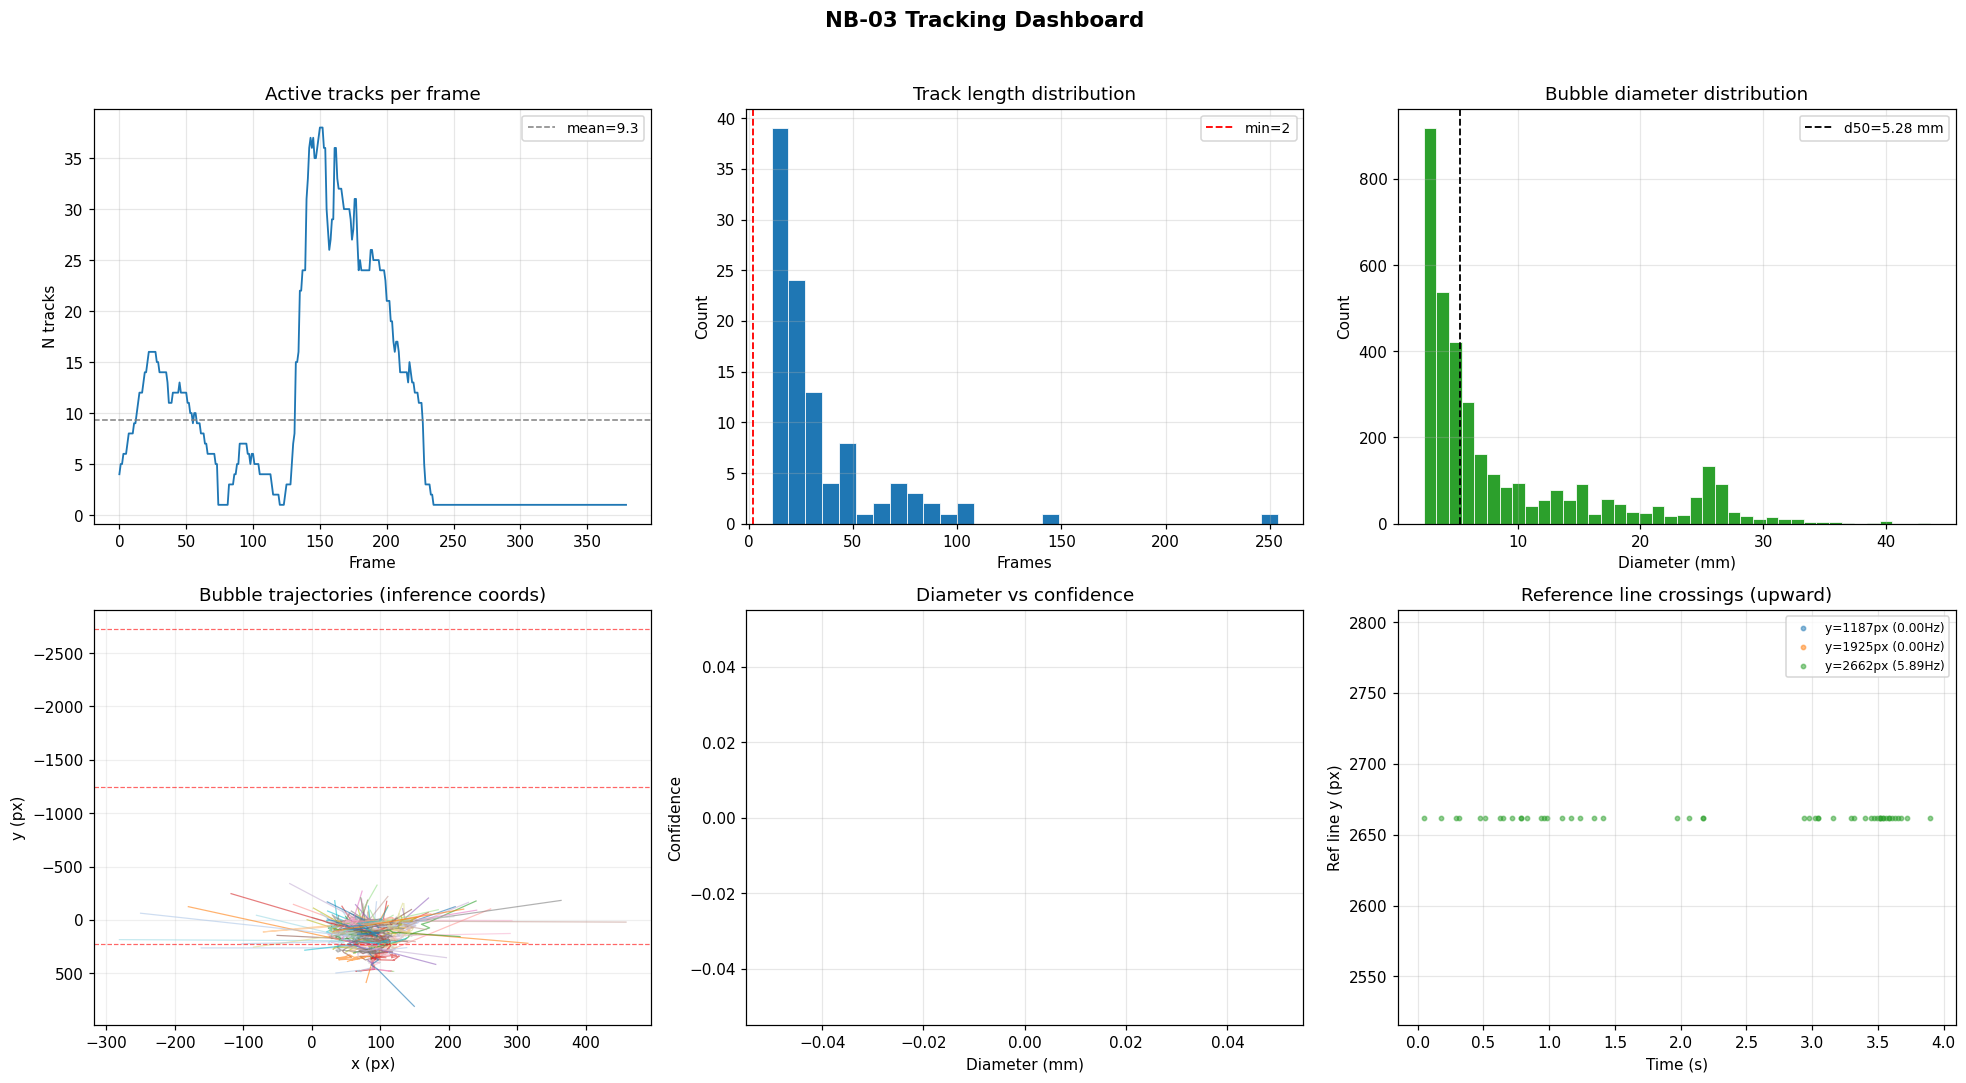

In [14]:
def safe_savefig(path, dpi=140):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    try:
        plt.savefig(path, dpi=dpi, bbox_inches='tight')
        print(f'[OK] {path}'); return path
    except Exception as e:
        fb = Path('/content/nb03_outputs') / path.name
        Path('/content/nb03_outputs').mkdir(parents=True, exist_ok=True)
        plt.savefig(fb, dpi=dpi, bbox_inches='tight')
        print(f'[OK fallback] {fb}'); return fb


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('NB-03 Tracking Dashboard', fontsize=14, fontweight='bold')

# Panel 1 — Active tracks per frame
ax = axes[0,0]
active_pf = df_tracks_raw.groupby('frame_id')['global_bubble_id'].nunique()
ax.plot(active_pf.index, active_pf.values, linewidth=1.2, color='tab:blue')
ax.axhline(active_pf.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'mean={active_pf.mean():.1f}')
ax.set_title('Active tracks per frame')
ax.set_xlabel('Frame'); ax.set_ylabel('N tracks')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Panel 2 — Track length distribution
ax = axes[0,1]
lengths = df_tracks_raw.groupby('global_bubble_id').size()
ax.hist(lengths.values, bins=max(3, min(30, len(lengths)//2)),
        color='tab:blue', edgecolor='white', linewidth=0.5)
ax.axvline(MIN_TRACK_LENGTH, linestyle='--', linewidth=1.2,
           color='red', label=f'min={MIN_TRACK_LENGTH}')
ax.set_title('Track length distribution')
ax.set_xlabel('Frames'); ax.set_ylabel('Count')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Panel 3 — Diameter distribution
ax = axes[0,2]
diam = df_tracks_raw['diameter_mm'].dropna()
ax.hist(diam.values, bins=40, color='tab:green', edgecolor='white', linewidth=0.5)
ax.axvline(diam.median(), color='black', linestyle='--', linewidth=1.2,
           label=f'd50={diam.median():.2f} mm')
ax.set_title('Bubble diameter distribution')
ax.set_xlabel('Diameter (mm)'); ax.set_ylabel('Count')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Panel 4 — Trajectories (all tracks)
ax = axes[1,0]
_colors_t = plt.cm.tab20.colors
for gi, (gid, g) in enumerate(df_tracks_raw.groupby('global_bubble_id')):
    if len(g) >= MIN_TRACK_LENGTH:
        ax.plot(g['cx'], g['cy'], linewidth=0.8, alpha=0.6,
                color=_colors_t[gi % len(_colors_t)])
for rl in REF_LINES_TRACK:
    ax.axhline(rl, linestyle='--', linewidth=0.8, color='red', alpha=0.6)
ax.invert_yaxis()
ax.set_title('Bubble trajectories (inference coords)')
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)'); ax.grid(alpha=0.2)

# Panel 5 — Diameter vs confidence
ax = axes[1,1]
ax.scatter(df_tracks_raw['diameter_mm'], df_tracks_raw['confidence'],
           s=8, alpha=0.4, color='tab:purple')
ax.set_title('Diameter vs confidence')
ax.set_xlabel('Diameter (mm)'); ax.set_ylabel('Confidence'); ax.grid(alpha=0.3)

# Panel 6 — Reference line crossings
ax = axes[1,2]
if not crossings_df.empty:
    for ly in REF_LINES_FULL:
        sub = crossings_df[(crossings_df['ref_line_y_orig_px']==ly)
                           & (crossings_df['direction']=='upward')]
        ax.scatter(sub['time_s'], [ly]*len(sub), s=8, alpha=0.5,
                   label=f'y={ly}px ({freq_per_line.get(ly,0):.2f}Hz)')
    ax.set_title('Reference line crossings (upward)')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Ref line y (px)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No crossings detected',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Reference line crossings')

plt.tight_layout(rect=[0,0,1,0.96])
safe_savefig(DASHBOARD_PATH)
plt.show()

---
## Cell 11 — Gate Report

In [15]:
from IPython.display import Markdown, display

n_tracks  = int(df_tracks_raw['global_bubble_id'].nunique())
n_frames  = int(df_tracks_raw['frame_id'].nunique())
lengths   = df_tracks_raw.groupby('global_bubble_id').size()
n_long    = int((lengths >= MIN_TRACK_LENGTH).sum())
p50       = float(lengths.quantile(0.50))
p95       = float(lengths.quantile(0.95))
short_rt  = float((lengths < MIN_TRACK_LENGTH).mean())
ev_dist   = df_events['event_type'].value_counts().to_dict() if not df_events.empty else {}
n_cross   = int(len(crossings_df))
expl_ok   = (n_tracks > 0 and n_frames > 0 and len(df_tracks_raw) > 0)

metrics = {
    'schema_version': '1.0',
    'created_at': datetime.now(timezone.utc).isoformat(),
    'run_label': RUN_LABEL, 'setup_id': SETUP_ID,
    'gate_pass': False, 'exploratory_ok': bool(expl_ok),
    'gate_reason': 'no_tracking_ground_truth',
    'n_total_tracks': n_tracks, 'n_long_tracks': n_long,
    'n_frames_tracked': n_frames,
    'track_length_p50': p50, 'track_length_p95': p95,
    'short_track_rate': short_rt,
    'event_distribution': ev_dist,
    'n_crossing_events': n_cross,
    'freq_per_ref_line_hz': {str(k): v for k, v in freq_per_line.items()},
    'idf1': None, 'mota': None,
    'roi_used': PREPROC_ROI,
    'ref_lines_full_px': REF_LINES_FULL,
    'ref_lines_track_px': REF_LINES_TRACK,
    'parameters': {
        'fps': FPS, 'mm_per_pixel': MM_PER_PIXEL,
        'max_dist_px': MAX_DIST_PX, 'max_lost_frames': MAX_LOST_FRAMES,
        'min_track_length': MIN_TRACK_LENGTH,
        'use_upward_gate': USE_UPWARD_GATE,
    }
}

TRACKING_GATE_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(TRACKING_GATE_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'[OK] tracking_gate.json: {TRACKING_GATE_PATH}')

# Per-method detection summary for report
_method_row = ''
if 'seg_mode' in df_det_raw.columns:
    for m in sorted(df_det_raw['seg_mode'].unique()):
        sub = df_det_raw[df_det_raw['seg_mode']==m]
        dpf = len(sub)/max(n_frames,1)
        _method_row += f'| {m} | {len(sub)} | {dpf:.2f} |\n'

report_md = f"""
## NB-03 · Tracking Gate Report  (v2)

**Run:** `{RUN_LABEL}` | **Setup:** `{SETUP_ID}`
**Timestamp:** {metrics['created_at']}
**ROI used:** `{PREPROC_ROI}` (from chunk_meta.json)
**Reference lines (full px):** `{REF_LINES_FULL}`

---
### Detection source (NB-02 output)

| Method | Detections | Det/frame |
|---|---|---|
{_method_row if _method_row else '| (seg_mode not in parquet) | — | — |'}

GT baseline: **5.84 det/frame** (147 annotated frames)

---
### Tracking results

| Field | Value |
|---|---:|
| **Status** | **{'EXPLORATORY OK' if expl_ok else 'NOT USABLE'}** |
| **Gate pass** | {'✅ MET' if metrics['gate_pass'] else '❌ NOT MET — no tracking GT'} |
| **Frames tracked** | {n_frames} |
| **Total tracks** | {n_tracks} |
| **Long tracks (≥{MIN_TRACK_LENGTH} frames)** | {n_long} |
| **Track length p50 / p95** | {p50:.0f} / {p95:.0f} frames |
| **Short-track rate** | {short_rt:.3f} |
| **Crossing events** | {n_cross} |
| **IDF1 / MOTA** | N/A — no manual tracking GT |

### Reference line crossing frequencies

| Line y (full px) | Frequency (Hz) |
|---|---|
{''.join(f'| {k} | {v:.4f} |' + chr(10) for k,v in freq_per_line.items()) if freq_per_line else '| — | — |'}

---
**Decision:** NB-04 may run for exploratory analysis (`exploratory_ok = {expl_ok}`).
Results are **not validated** until manual tracking GT is provided and IDF1/MOTA computed.
"""

display(Markdown(report_md))

[OK] tracking_gate.json: /content/drive/MyDrive/SIGNAL_NN_2026/HIDRO_2026/campaigns/setup_A/outputs/tracking/tracking_gate.json



## NB-03 · Tracking Gate Report  (v2)

**Run:** `run_001_Q10` | **Setup:** `setup_A`
**Timestamp:** 2026-06-02T12:58:32.946334+00:00
**ROI used:** `[900, 2550, 1260, 3520]` (from chunk_meta.json)
**Reference lines (full px):** `[1187, 1925, 2662]`

---
### Detection source (NB-02 output)

| Method | Detections | Det/frame |
|---|---|---|
| classical | 1979 | 5.24 |


GT baseline: **5.84 det/frame** (147 annotated frames)

---
### Tracking results

| Field | Value |
|---|---:|
| **Status** | **EXPLORATORY OK** |
| **Gate pass** | ❌ NOT MET — no tracking GT |
| **Frames tracked** | 378 |
| **Total tracks** | 105 |
| **Long tracks (≥2 frames)** | 105 |
| **Track length p50 / p95** | 22 / 90 frames |
| **Short-track rate** | 0.000 |
| **Crossing events** | 71 |
| **IDF1 / MOTA** | N/A — no manual tracking GT |

### Reference line crossing frequencies

| Line y (full px) | Frequency (Hz) |
|---|---|
| 1187 | 0.0000 |
| 1925 | 0.0000 |
| 2662 | 5.8889 |


---
**Decision:** NB-04 may run for exploratory analysis (`exploratory_ok = True`).
Results are **not validated** until manual tracking GT is provided and IDF1/MOTA computed.
